# Transient

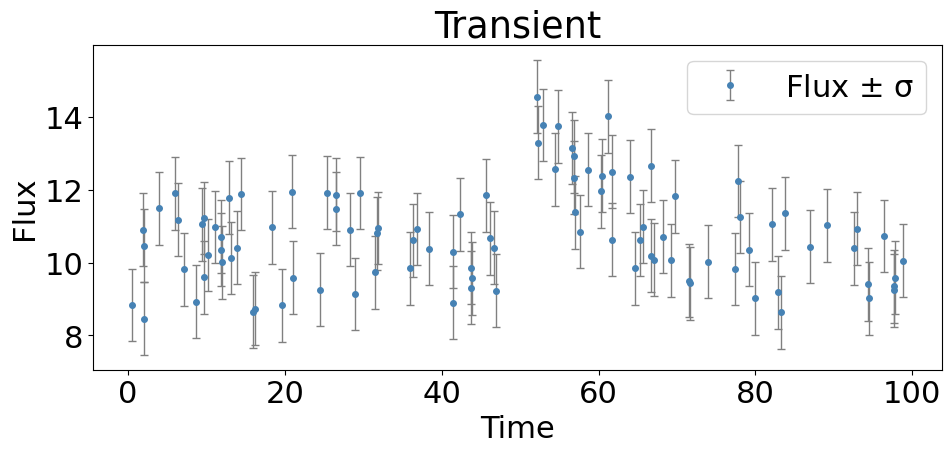

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

data = np.load("transient.npy")

time  = data[:, 0]   
flux  = data[:, 1]   
sigma = data[:, 2]   

fig, ax = plt.subplots(figsize=(10, 5))

ax.errorbar(
    time, flux, yerr=sigma, fmt="o", markersize=4, capsize=3, color="steelblue", ecolor="gray", elinewidth=1, label=f"Flux $\pm$ σ")

ax.set_xlabel("Time")
ax.set_ylabel("Flux")
ax.set_title("Transient")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
import emcee

In [63]:
def burst_model(t, b, A, t0, alpha):
    return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))

def log_likelihood(params, t, flux_obs, sigma):
    b, A, t0, ln_alpha = params
    alpha = np.exp(ln_alpha)
    model = burst_model(t, b, A, t0, alpha)
    return -0.5 * np.sum(((flux_obs - model) / sigma) ** 2)

def log_prior(params):
    b, A, t0, ln_alpha = params
    if 0 < b < 50 and 0 < A < 50 and 0 < t0 < 100 and -5 < ln_alpha < 5:
        return 0.0
    return -np.inf

def myLogPosterior(params, t, flux_obs, sigma):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return log_likelihood(params, t, flux_obs, sigma) + lp

In [185]:
ndim = 4  # number of parameters in the model
nwalkers = 12  # number of MCMC walkers
burn = 1000  # "burn-in" period to let chains stabilize
nsteps = 10000 # number of MCMC steps to take **for each walker**

# initialize theta 
np.random.seed(0)

p0 = np.array([10.0, 5.0, 50, -1.0]) 
starting_guesses = p0 + 1e-3 * np.random.randn(nwalkers, ndim)

# the function call where all the work happens: 
sampler = emcee.EnsembleSampler(nwalkers, ndim, myLogPosterior, args=[time, flux, sigma])
sampler.run_mcmc(starting_guesses, nsteps)

# sampler.chain is of shape (nwalkers, nsteps, ndim)
# throw-out the burn-in points and reshape:
emcee_trace  = sampler.chain[:, burn:, :].reshape(-1, ndim)

print("done")


done


In [186]:
print(sampler.chain.shape) #original chain structure
print(emcee_trace.shape) #burned and flattened chain

(12, 10000, 4)
(108000, 4)


In [187]:
emcee_trace.flatten()
len(emcee_trace.flatten())

432000

In [188]:
# Now take one point every autocorrelation lenght
tau = sampler.get_autocorr_time() #Mi dice: ogni quanti passi ho un campione indipendente
print(tau)
thin = int(np.max(tau)) + 1 #Prendo il caso peggiore

#Ogni 102 passi ho un campione indipendente. DOvrei aumentare il numero di passi!

[ 63.26581817 132.42325507 125.17097131  42.45831851]


In [189]:
emcee_trace = sampler.get_chain(discard=burn, thin=thin, flat=True)

In [190]:
len(emcee_trace)

804

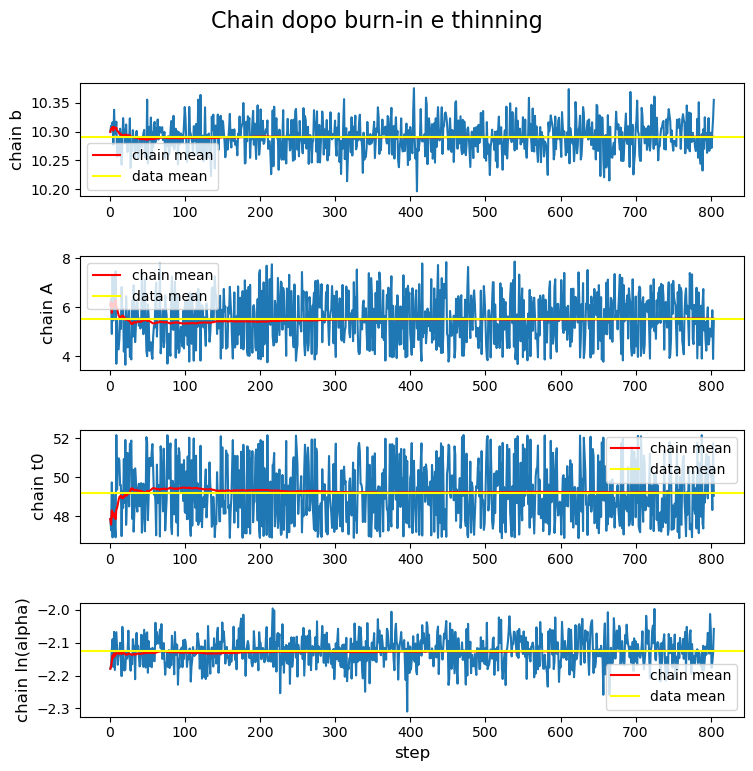

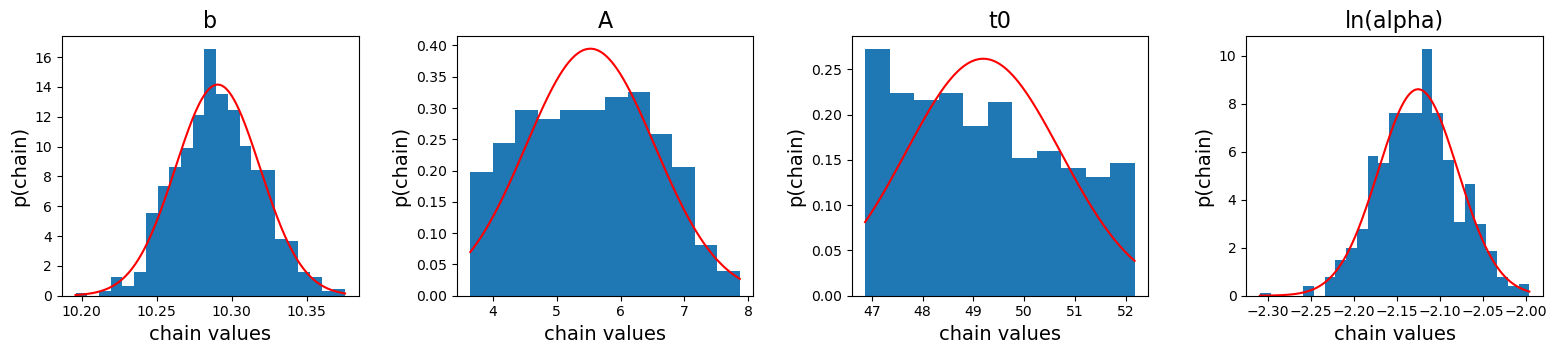

In [192]:
labels = ['b', 'A', 't0', 'ln(alpha)']

fig, axes = plt.subplots(4, 1, figsize=(8, 8))
for i, (ax, label) in enumerate(zip(axes, labels)):
    chainE = emcee_trace
    M = len(chainE)
    xgrid = np.arange(1, M+1)
    meanC = [np.mean(chainE[:int(N), i]) for N in xgrid]

    ax.plot(xgrid, emcee_trace[:, i]) #trace
    ax.plot(xgrid, meanC, c='red', label='chain mean') 
    ax.axhline(np.mean(chainE[:, i]), c='yellow', label='data mean')
    
    ax.set_ylabel(str('chain ')+label, fontsize = 12)
    ax.tick_params(axis='both', labelsize=10)
    ax.legend(fontsize = 10)
    
axes[-1].set_xlabel('step', fontsize = 12)
plt.suptitle('Chain dopo burn-in e thinning', fontsize = 16)
plt.tight_layout()

plt.show()


fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (ax, label) in enumerate(zip(axes, labels)):
    counts, bins, _ = ax.hist(emcee_trace[:, i], bins='auto', histtype='stepfilled', density=True)
    
    ax.set_title(label, fontsize=16)
    ax.set_xlabel('chain values', fontsize=14)
    ax.set_ylabel('p(chain)', fontsize=14)
    ax.tick_params(axis='both', labelsize=10)
    
    mu = np.mean(emcee_trace[:, i])
    sigma = np.std(emcee_trace[:, i])
    x = np.linspace(np.min(emcee_trace[:, i]), np.max(emcee_trace[:, i]), 500)
    gauss = stats.norm(mu, sigma).pdf(x)
    ax.plot(x, gauss, c='red')
    

plt.tight_layout()
plt.show()


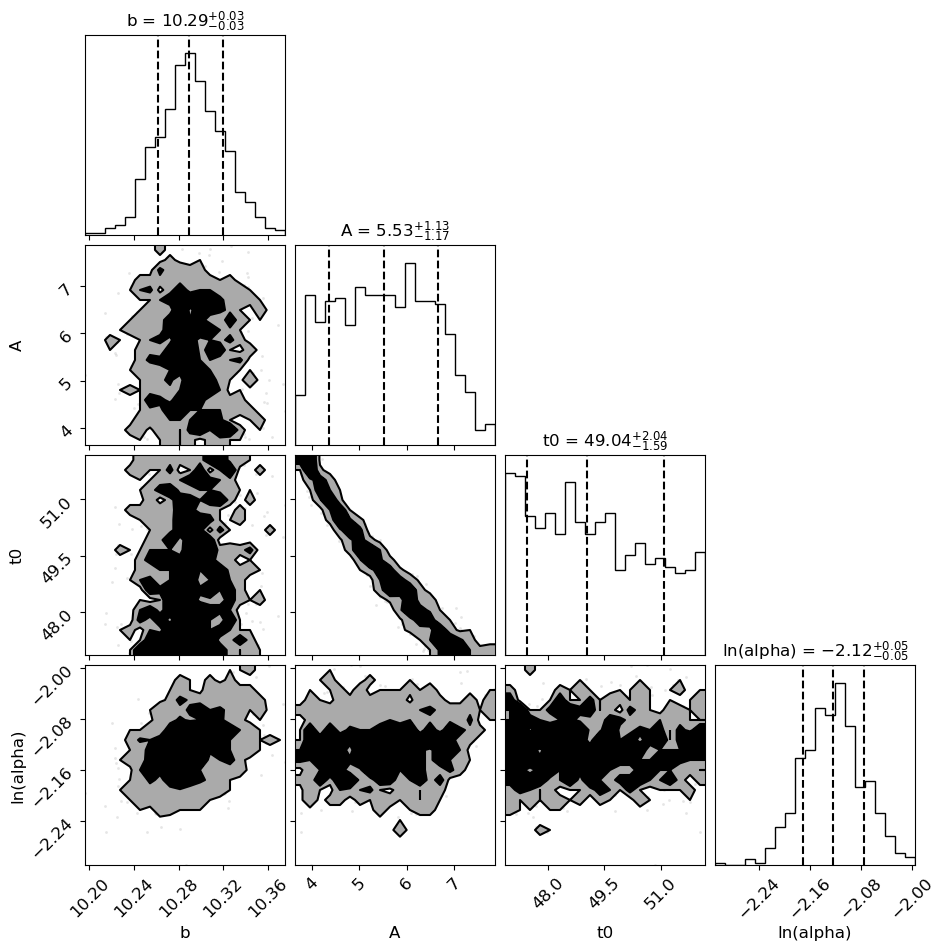

In [194]:
import corner
fig = corner.corner(
    emcee_trace,
    labels=labels,
    label_kwargs={"fontsize": 12},
    show_titles=True,
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    levels=[0.68, 0.95],
    fill_contours=True
)

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=12)

plt.savefig("grafico.png")
plt.show()

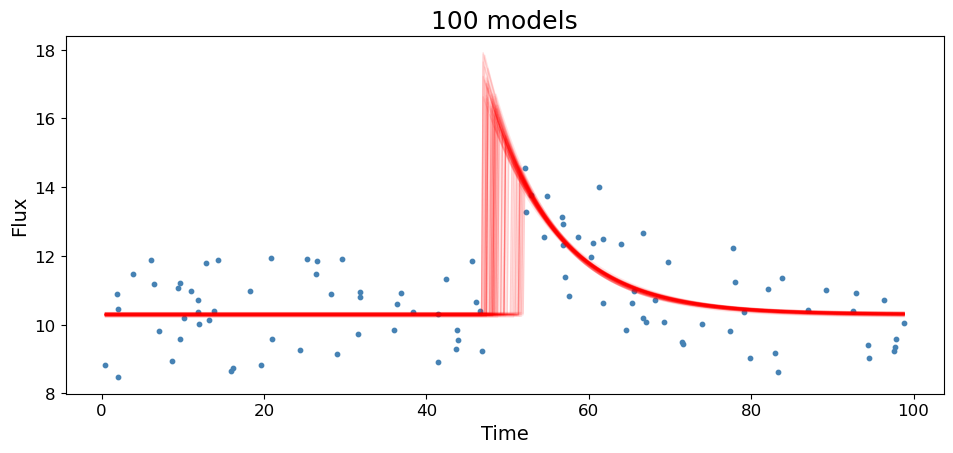

In [209]:
t_grid = np.linspace(time.min(), time.max(), 500)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(time, flux, s=10, marker='o', color="steelblue", label="data")

indices = np.random.choice(len(emcee_trace), size=100, replace=False)
for i in indices:
    b, A, t0, ln_alpha = emcee_trace[i]
    alpha = np.exp(ln_alpha)
    curve = burst_model(t_grid, b, A, t0, alpha)
    ax.plot(t_grid, curve, color="red", alpha=0.1, lw=1)

ax.set_xlabel("Time", fontsize = 14)
ax.set_ylabel("Flux", fontsize = 14)
ax.set_title("100 models", fontsize = 18)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()